# **California-Housing-Preprocessing-AI**

STEP 1: ANALISI, PULIZIA E GESTIONE DATI MANCANTI

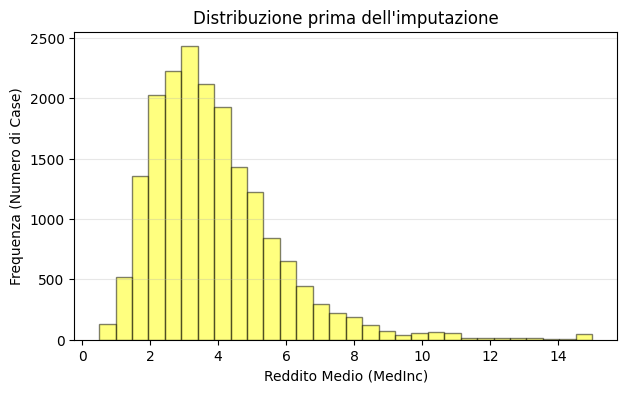

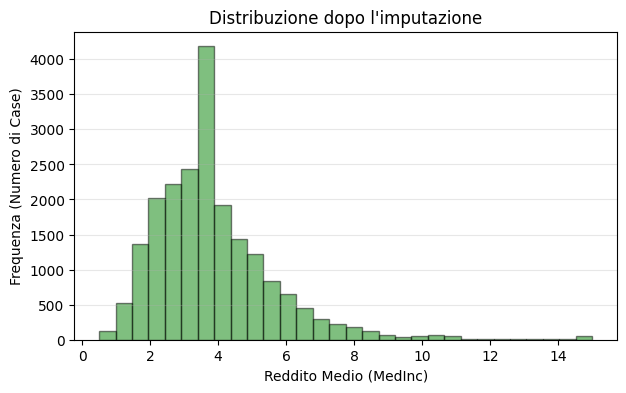

L'istogramma dopo l'imputazione mostra un picco in corrispondenza della mediana. Questo conferma che i NaN sono stati gestiti correttamente senza alterare la forma generale della distribuzione del reddito


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.impute import SimpleImputer

#carico il dataset e aggiungo la colonna categorica e i valori nan
X, y = fetch_california_housing(return_X_y = True, as_frame = True)
df = pd.DataFrame(X)
#inserimento variabile categoria
categorie = ["NEAR OCEAN", "IN LAND", "ISLAND"]
np.random.seed(42)
df["Categoria"] = np.random.choice(categorie, size = len(df))

df["Valore"] = y
#inserimento nan
#calcolO il numero di righe che corrispondono al 10%
n_missing = int(len(df) * 0.1)
#genero casualmente gli indici delle righe
indices_nan = np.random.choice(df.index, size=n_missing, replace=False)
#adesso inserisco i nan sul 10 per cento delle righe sulla colonna "MedInc"
df.loc[indices_nan, "MedInc"] = np.nan

#clono il dataframe originale
df_originale = df.copy()
#sostituisco il dataframe con un nuovo dove nella prima colonna ho eseguito la
#imputazione univariata con la mediana che è il valore centrale della distribuzione
#quindi resistente agli outlier
imputer = SimpleImputer(strategy = "median")
cols_numeriche = df_originale.select_dtypes(include=[np.number]).columns
df[cols_numeriche] = imputer.fit_transform(df[cols_numeriche])
#visualizzazione: istogramma dataset originale
plt.figure(figsize=(7, 4))

#dropna() è necessario per visualizzare solo i dati esistenti senza errori
plt.hist(df_originale["MedInc"].dropna(), bins=30, alpha=0.5,  color="yellow", edgecolor="black")

plt.title("Distribuzione prima dell'imputazione")
plt.xlabel("Reddito Medio (MedInc)")
plt.ylabel("Frequenza (Numero di Case)")
plt.grid(axis='y', alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4))

plt.hist(df["MedInc"], bins=30, alpha=0.5, color='green', edgecolor='black')

plt.title("Distribuzione dopo l'imputazione")
plt.xlabel("Reddito Medio (MedInc)")
plt.ylabel("Frequenza (Numero di Case)")
plt.grid(axis='y', alpha=0.3)
plt.show()

#L'istogramma dopo l'imputazione mostra un picco in corrispondenza della mediana.
#Questo conferma che i NaN sono stati gestiti correttamente senza alterare la forma generale della distribuzione del reddito

STEP 2: TRASFORMAZIONE DELLE CARATTERISTICHE (CATEGORICHE E NUMERICHE)

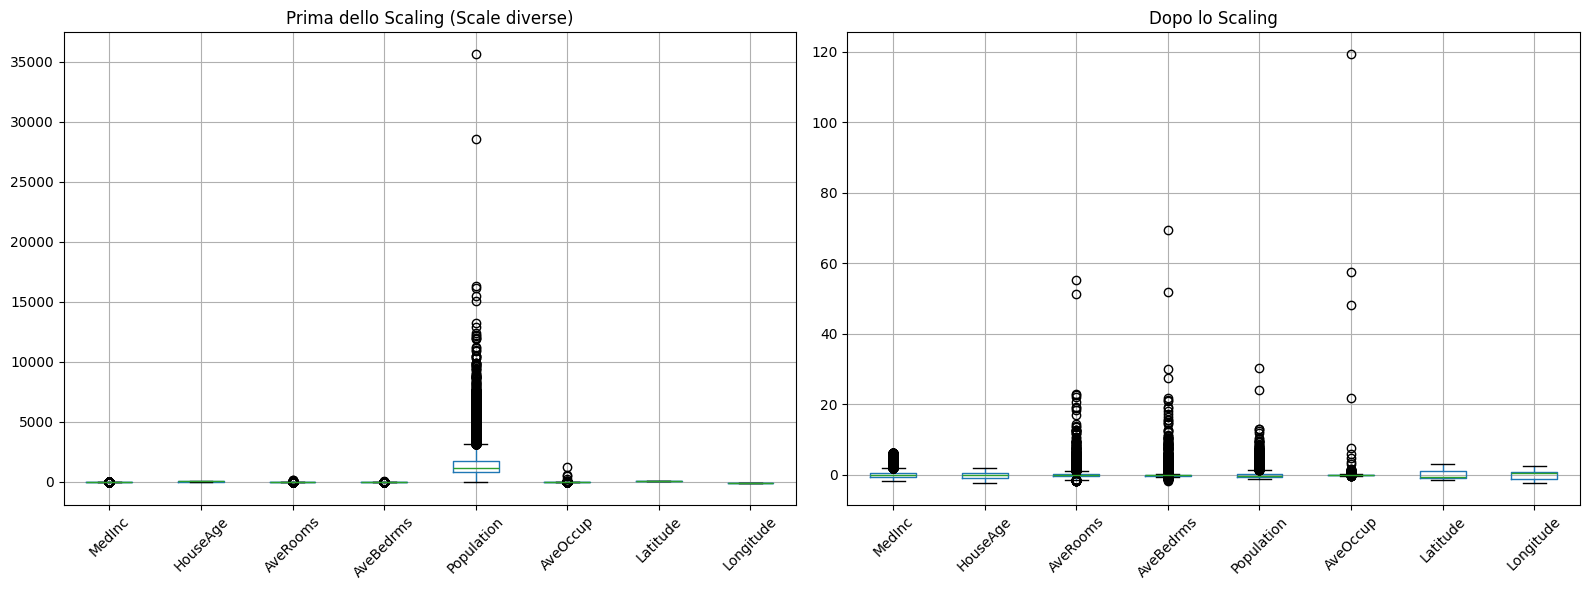

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
#uso il onehotencoder perchè mi permette di non imporre un ordine
encoder = OneHotEncoder(sparse_output=False)
encoded_features = encoder.fit_transform(df_originale[["Categoria"]])
#in questo caso non c'è rischio di maledizione della dimensionalità
#perchè il numero di colonne è molto minore rispetto a quello dei campioni
#recupero dei nomi delle nuove colonne es "Categoria_ISLAND" ecc.
nomi_colonne = encoder.get_feature_names_out(["Categoria"])

#creazione nuovo dataframe con le features nuove
#creazione di un DataFrame temporaneo con le nuove colonne
df_nuove_colonne = pd.DataFrame(encoded_features, columns=nomi_colonne, index=df.index)
#Concatenazione orizzontale (axis=1)
df_intermedio = pd.concat([df, df_nuove_colonne], axis=1)
#rimozione della vecchia colonna testuale
df_intermedio = df_intermedio.drop("Categoria", axis=1)
#copia
df_finale = df_intermedio.copy()

# Seleziona solo le colonne che erano numeriche in origine
cols_da_scalare = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

#trasformazione numeriche solo alle colonne numeriche originarie
scaler = StandardScaler()
df_finale[cols_da_scalare] = scaler.fit_transform(df_intermedio[cols_da_scalare])

#visualizzazione delle differenze prima e dopo lo scaling
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

#df_intermedio
#uso solo le colonne originali
df_intermedio[cols_da_scalare].boxplot(ax=ax1)
ax1.set_title("Prima dello Scaling (Scale diverse)")
ax1.tick_params(axis='x', rotation=45)

#df_finale
df_finale[cols_da_scalare].boxplot(ax=ax2)
ax2.set_title("Dopo lo Scaling")
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

#Il Box Plot "Dopo lo Scaling" mostra che tutte le feature sono ora centrate sullo zero con una varianza simile.
#Questo è essenziale perché la PCA è sensibile alle diverse scale delle variabili.

STEP 3: RIDUZIONE DELLA DIMENSIONALITA E VISUALIZZAZIONE

Numero di componenti estratte: 2
Varianza totale preservata con 2 PC: 45.02%
Con questa varianza c'è perdita di informazione e i cluster non sono naturali


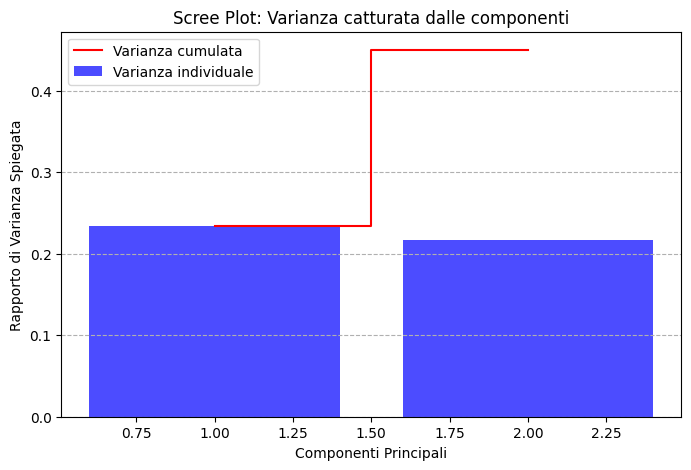

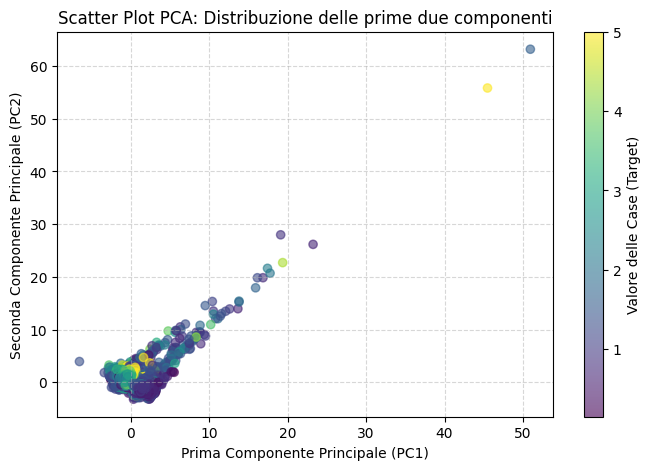

In [ ]:
from sklearn.decomposition import PCA

X = df_finale.drop("Valore", axis=1)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

n_componenti = pca.n_components_
varianza_totale = np.sum(pca.explained_variance_ratio_) * 100
print(f"Numero di componenti estratte: {n_componenti}")
print(f"Varianza totale preservata con 2 PC: {varianza_totale:.2f}%")
print("Con questa varianza c'è perdita di informazione e i cluster non sono naturali")

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])

#scree plot
plt.figure(figsize=(8, 5))
plt.bar(range(1, n_componenti + 1), pca.explained_variance_ratio_, alpha=0.7, color='blue', label='Varianza individuale')
plt.step(range(1, n_componenti + 1), np.cumsum(pca.explained_variance_ratio_), where='mid', label='Varianza cumulata', color='red')

plt.xlabel('Componenti Principali')
plt.ylabel('Rapporto di Varianza Spiegata')
plt.title('Scree Plot: Varianza catturata dalle componenti')
plt.legend(loc='best')
plt.grid(axis='y', linestyle='--')
plt.show()

#scatter plot
plt.figure(figsize=(8, 5))

#uso c=df_originale['Valore'] per colorare i punti in base al prezzo
scatter = plt.scatter(df_pca['PC1'], df_pca['PC2'],
                      c=df_originale['Valore'],
                      cmap='viridis',
                      alpha=0.6)

plt.xlabel('Prima Componente Principale (PC1)')
plt.ylabel('Seconda Componente Principale (PC2)')
plt.title('Scatter Plot PCA: Distribuzione delle prime due componenti')
#barra di colori
plt.colorbar(scatter, label='Valore delle Case (Target)')

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#sebbene 2 componenti siano ottime per la visualizzazione (Scatter Plot),
#per un modello di produzione reale potreI aver bisogno di più componenti per
#raggiungere il 90% di varianza ed evitare una perdita eccessiva di dati.

STEP 4: BILANCIAMENTO DELLE CLASSI E WORKFLOW

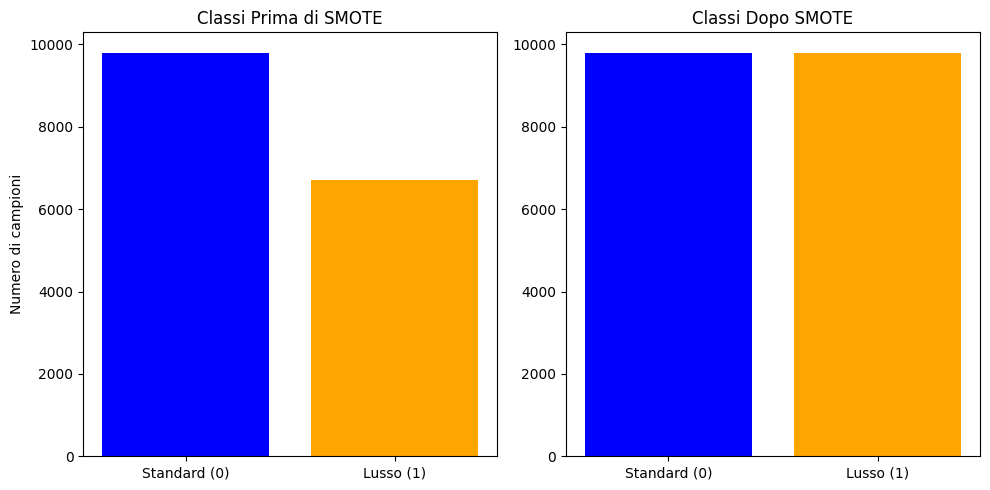

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

#uso la media per sbilanciare le classi
soglia = df_originale['Valore'].mean()
y_class = (df_originale['Valore'] > soglia).astype(int)


X_train, X_test, y_train, y_test = train_test_split(
    df_intermedio,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)


workflow = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2))
])

X_train_final = workflow.fit_transform(X_res)

X_test_final = workflow.transform(X_test)

classi_prima = y_train.value_counts()
classi_dopo = y_res.value_counts()


plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.bar(['Standard (0)', 'Lusso (1)'], classi_prima.values, color=['blue', 'orange'])
plt.title("Classi Prima di SMOTE")
plt.ylabel("Numero di campioni")

plt.subplot(1, 2, 2)
plt.bar(['Standard (0)', 'Lusso (1)'], classi_dopo.values, color=['blue', 'orange'])
plt.title("Classi Dopo SMOTE")

plt.tight_layout()
plt.show()

#Il grafico a barre conferma che la classe "Lusso" (minoritaria a causa della
#soglia impostata sulla media) è stata pareggiata artificialmente.